# Chapter 8: Hyperparameter optimization

In this chapter we will see how cross-validation and Bayesian techniques can be used for hyperparameter optimization of machine learning models.

In [2]:
# Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from pathlib import Path

import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim

# wrapper of PyTorch models so they can be used as if they were scikit-learn models
import skorch

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

path_pardir = Path(os.getcwd()).parent
path_data = os.path.join(path_pardir, 'Data')

# Define the device choosing cuda if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fix random seed for reproducibility
rng = np.random.RandomState(42)

Device: cpu


## S8-1: Grid search with cross-validation

We use again the data of Chapter 1, and train a simple classification model.

Training samples: 4000
Test samples: 500


<Axes: xlabel='x_range', ylabel='y_range'>

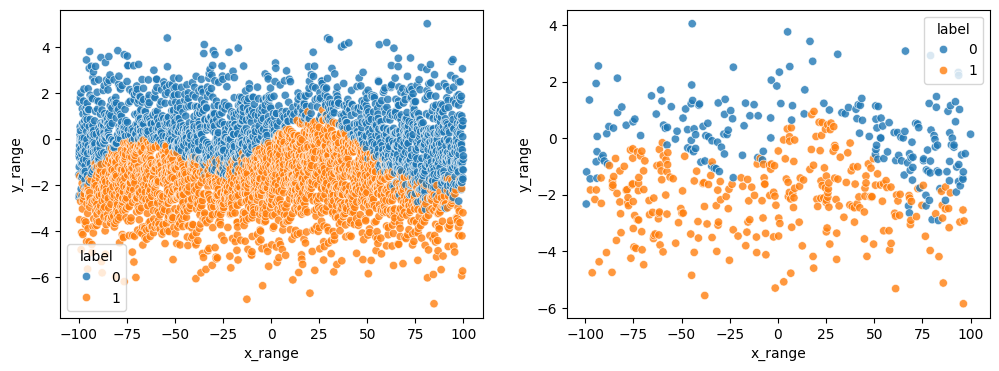

In [4]:
chosen_df = "df_classification_large.csv"

full_df = pd.read_csv(os.path.join(path_data, chosen_df))

# predefined split
# we consider the predefined training (split_label=0) and test (split_label=2),
# ignoring the predefined validation set since we will define our custom validation split later, during cross-validation
training_df = full_df[full_df["split_label"]==0]
test_df = full_df[full_df["split_label"]==2]

print("Training samples:", training_df.shape[0])
print("Test samples:", test_df.shape[0])

fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Scatter plot
sns.scatterplot(data=training_df, x="x_range", y="y_range", hue="label", alpha = 0.8, ax = axs[0])
sns.scatterplot(data=test_df, x="x_range", y="y_range", hue="label", alpha = 0.8, ax = axs[1])

As an example, we choose a Random Forest model from scikit-learn with some modified parameters, purposefully weakening the model. At first we train it on the training set and evaluate on the test set, without doing any cross-validation.

In [5]:
rfc = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=rng) # error!

X = training_df[["x_range", "y_range"]]
y = training_df["label"]

rfc.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

Test accuracy: 0.91000


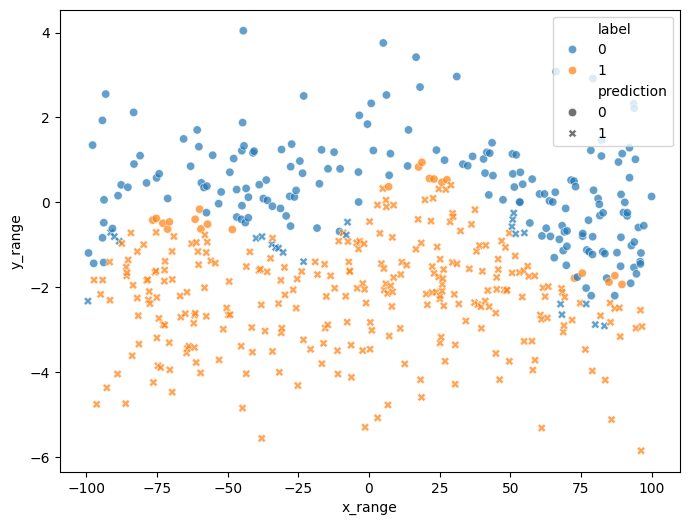

In [6]:
Xtest = test_df[["x_range", "y_range"]]
ytest = test_df["label"]
yhat = rfc.predict(Xtest)

df_plot = test_df[["x_range", "y_range", "label"]]
df_plot["prediction"] = yhat

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Scatter plot
sns.scatterplot(data=df_plot, x="x_range", y="y_range", hue="label", style="prediction", alpha = 0.7, ax = ax)
print("Test accuracy:", f"{accuracy_score(ytest, yhat):.5f}")

Let's check the model generalization capability using cross-validation. We use the standard scikit-learn function `cross_val_score`. Please note that by default the folds are stratified by the label for binary or multiclass classification (as it is this case), but the samples are **not** shuffled, therefore we define an instance of `StratifiedKFold` with `shuffle=True`. For more info see the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng) # fix seed for reproducibility
cv_scores = cross_val_score(rfc, X, y, cv=cv) # by default the score of a classifier is the accuracy
print(cv_scores)
print("Mean:", cv_scores.mean(), "Std:", cv_scores.std())

[0.95375 0.94375 0.945   0.95875 0.9375 ]
Mean: 0.9477499999999999 Std: 0.007558108228915488


Now let's use CV to fine tune some hyperparameters of the model. For this example we will use a simple grid search on two hyperparameters:

- `n_estimators`: the number of decision trees in the forest. We use as candidates `[10, 50, 100, 200]`
- `max_depth`: the maximum depth of the trees. We use `[10, 20, None]`, where `None` means that a tree can grow until either all its leaves are pure or contain less than `min_samples_split` samples.

In [6]:
grid = {"n_estimators": [10, 50, 100, 200], "max_depth": [10, 20, None]}

grid_rfc = GridSearchCV(estimator=rfc, param_grid=grid, cv=cv, verbose=3)
grid_rfc.fit(X, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END .....max_depth=10, n_estimators=10;, score=0.932 total time=   0.0s
[CV 2/5] END .....max_depth=10, n_estimators=10;, score=0.940 total time=   0.0s
[CV 3/5] END .....max_depth=10, n_estimators=10;, score=0.970 total time=   0.0s
[CV 4/5] END .....max_depth=10, n_estimators=10;, score=0.956 total time=   0.0s
[CV 5/5] END .....max_depth=10, n_estimators=10;, score=0.944 total time=   0.0s
[CV 1/5] END .....max_depth=10, n_estimators=50;, score=0.943 total time=   0.1s
[CV 2/5] END .....max_depth=10, n_estimators=50;, score=0.951 total time=   0.1s
[CV 3/5] END .....max_depth=10, n_estimators=50;, score=0.966 total time=   0.1s
[CV 4/5] END .....max_depth=10, n_estimators=50;, score=0.959 total time=   0.1s
[CV 5/5] END .....max_depth=10, n_estimators=50;, score=0.951 total time=   0.1s
[CV 1/5] END ....max_depth=10, n_estimators=100;, score=0.939 total time=   0.2s
[CV 2/5] END ....max_depth=10, n_estimators=100;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...x7E1BCC0B1240)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : th

Train accuracy: 0.99200
Test accuracy: 0.94800


<Axes: xlabel='x_range', ylabel='y_range'>

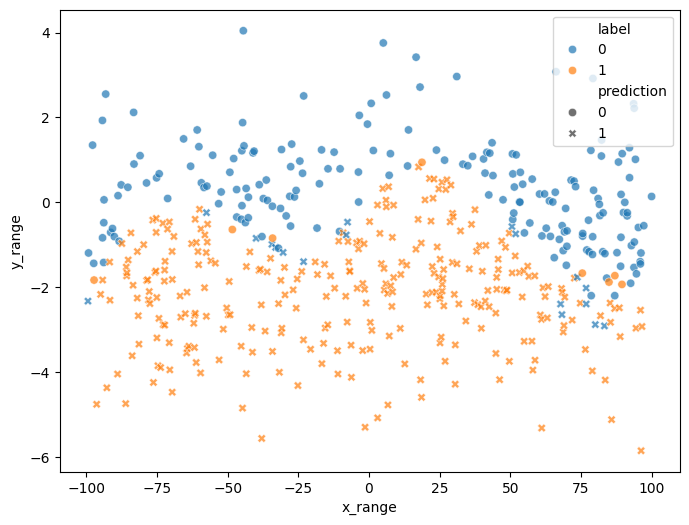

In [7]:
yhat_train = grid_rfc.predict(X)
yhat_test = grid_rfc.predict(Xtest)

print("Train accuracy:", f"{accuracy_score(y, yhat_train):.5f}")
print("Test accuracy:", f"{accuracy_score(ytest, yhat_test):.5f}")

df_plot = test_df[["x_range", "y_range", "label"]]
df_plot["prediction"] = yhat_test

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Scatter plot of test
sns.scatterplot(data=df_plot, x="x_range", y="y_range", hue="label", style="prediction", alpha = 0.7, ax = ax)

## S8-2: Grid search with cross-validation for Deep Neural Networks

Now we implement a cross-validation scheme to compare the Random Forest Classifier above with a simple Fully Connected deep neural network. The hyperparameters of the DNN are:

- number of hidden layers, varying in `[1, 2, 3]`
- width of hidden layer, varying in `[4, 8, 16]`

We use the Python package `skorch` (= scikit-learn + pytorch), which provides a wrapper of PyTorch models so that the functions of scikit-learn can be used with them.

In [8]:
class FullyConnected(nn.Module):

    def __init__(self, layer_widths):
        # layer_width is a list of the number of neuron for hidden layers
        # considering that the first layer takes two inputs (x,y-coordinates)
        # and the last layer returns a single output (label probability)
        # there is no softmax because it is dealt with BCEWithLogitsLoss for efficiency
        # example: layer_widths=[4, 6] means that there are three layers in total:
        # - input layer Linear(2, 4)
        # - hidden layer Linear(4, 6)
        # - output layer Linear(6, 1)
        super().__init__()
        # determine in_features and out_features for each layer
        n_layers = len(layer_widths)
        feats = [(2, layer_widths[0])]
        for i in range(n_layers-1):
            feats.append((layer_widths[i], layer_widths[i+1]))
        feats.append((layer_widths[-1], 1))
        layers = []
        for f in range(len(feats)-1):
            layers.append(nn.Linear(*feats[f]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(*feats[-1]))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = self.model(x)
        return x

model = skorch.NeuralNetBinaryClassifier(
    FullyConnected,
    criterion=nn.BCEWithLogitsLoss,
    optimizer=optim.Adam,
    max_epochs=30,
    batch_size=10
)

Xtorch = torch.tensor(X.to_numpy(), dtype=torch.float32)
ytorch = torch.tensor(y.to_numpy(), dtype=torch.float32)

grid = {"module__layer_widths": [[4], [8], [16]] + \
                                [[i, j] for i in [4, 8, 16] for j in [4, 8, 16]] + \
                                [[i, j, k] for i in [4, 8, 16] for j in [4, 8, 16] for k in [4, 8, 16]]
       }

grid_dnn = GridSearchCV(estimator=model, param_grid=grid, cv=cv, verbose=3)
grid_dnn_results = grid_dnn.fit(Xtorch, ytorch)

print(f"Best setup: {grid_dnn_results.best_params_} obtaining accuracy {grid_dnn_results.best_score_}")

Fitting 5 folds for each of 39 candidates, totalling 195 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5324       0.5594        1.6938  0.1432
      2        0.2601       0.4875        2.4286  0.1686
      3        0.2189       0.4844        3.3815  0.1670
      4        0.2425       0.4813        3.9000  0.1617
      5        0.2486       0.4875        3.5261  0.1294
      6        0.2372       0.4953        3.2848  0.1975
      7        0.2348       0.5078        3.0833  0.3215
      8        0.2327       0.5156        2.9758  0.3221
      9        0.2307       0.5188        3.0066  0.3216
     10        0.2324       0.5219        2.9666  0.3217
     11        0.2331       0.5234        2.9509  0.3224
     12        0.2322       0.5266        2.9546  0.3216
     13        0.2347       0.5484        2.8019  0.3194
     14        0.2282       0.5422        2.8850  0.2344
     15        0.2328     

## S8-3: Hyperparameter optimization for DNN

In this section we show a Python package, called `optuna`, for the hyperparameter optimization with Bayesian techniques. In particular, the default optimizer (used below) is the Tree-structured Parzen Estimator. In the following, we optimize the number of layers and the width of a simple fully-connected network for the classification over the usual dataset. For simplicity we target the accuracy on the predefined validation set, without implementing a cross-validation scheme.

In [9]:
import optuna

# Dataset definition:
class CustomDataset(Dataset):
    def __init__(self, annotations_file, path_data, split_label=None):
        if split_label!=None:
            self.df = pd.read_csv(os.path.join(path_data, annotations_file))
            self.df = self.df[self.df['split_label']==split_label]
        else:
            self.df = pd.read_csv(os.path.join(path_data, annotations_file))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        x_range = float(self.df.iloc[idx]['x_range'])
        y_range = float(self.df.iloc[idx]['y_range'])
        features = torch.tensor([x_range, y_range], dtype=torch.float32)
        
        label = self.df.iloc[idx]['label']

        return features, torch.tensor(label, dtype=torch.float32)


training_dataset = CustomDataset(annotations_file=chosen_df, path_data=path_data, split_label=0)
training_dataloader = DataLoader(training_dataset, batch_size=10, shuffle=True)
valid_dataset = CustomDataset(annotations_file=chosen_df, path_data=path_data, split_label=1)
valid_dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_dataset = CustomDataset(annotations_file=chosen_df, path_data=path_data, split_label=2)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# define an objective function that returns the metric that we want to optimize
# in this case, accuracy
def objective(trial):
    # hyperparameter to be tuned: number of layers
    n_layers = trial.suggest_int("n_layers", 1, 3)
    layers = []
    in_features = 2
    for i in range(n_layers):
        # hyperparameter to be tuned: number of neurons per layer
        out_features = trial.suggest_int(f"n_units_l{i}", 4, 16)
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.ReLU())
        in_features = out_features
    layers.append(nn.Linear(in_features, 1))

    model = nn.Sequential(*layers).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    # training cycle
    n_epochs = 30
    for epoch in tqdm(range(n_epochs)):
        model.train()
        for x, y in training_dataloader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            yhat = model(x)
            loss = criterion(yhat, y.unsqueeze(1))
            loss.backward()
            optimizer.step()
    # after training, compute accuracy on validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in valid_dataloader:
            x = x.to(device)
            yhat = model(x).to("cpu")
            preds = (torch.sigmoid(yhat) >= 0.5).int()
            correct += preds.eq(y.view_as(preds)).sum().item()
    accuracy = correct / len(valid_dataset)
    return accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best trial:")
trial = study.best_trial

print("  Value:", trial.value)
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")


[I 2026-03-23 23:03:28,197] A new study created in memory with name: no-name-80381c01-484f-4b4d-a64c-95326c9cbc60
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:18<00:00,  1.62it/s]
[I 2026-03-23 23:03:46,908] Trial 0 finished with value: 0.928 and parameters: {'n_layers': 1, 'n_units_l0': 8}. Best is trial 0 with value: 0.928.
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:19<00:00,  1.50it/s]
[I 2026-03-23 23:04:07,019] Trial 1 finished with value: 0.91 and parameters: {'n_layers': 2, 'n_units_l0': 14, 'n_units_l1': 16}. Best is trial 0 with value: 0.928.
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:20<00:00,  1.50it/s]
[I 2026-03-23 23:04:27,210] Trial 2 finished with value: 0.926 and parameters: {'n_layers

Best trial:
  Value: 0.944
  Params:
    n_layers: 3
    n_units_l0: 8
    n_units_l1: 8
    n_units_l2: 11


Finally do a train cycle of the model with the best hyperparameters and evaluate on test

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:22<00:00,  1.33it/s]


Train accuracy: 0.92675
Test accuracy: 0.91600


<Axes: xlabel='x_range', ylabel='y_range'>

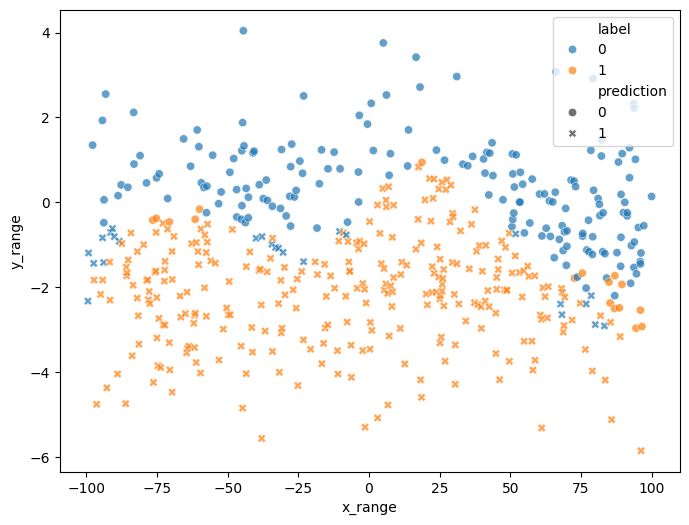

In [10]:
best_layers = [8, 8, 11]

model = FullyConnected(best_layers)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# training cycle
n_epochs = 30
for epoch in tqdm(range(n_epochs)):
    model.train()
    for x, y in training_dataloader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        yhat = model(x)
        loss = criterion(yhat, y.unsqueeze(1))
        loss.backward()
        optimizer.step()


def get_predictions(model, dataloader, device):
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xy_input, label_gt in dataloader:
            xy_input = xy_input.to(device)
            label_gt = label_gt.to(device)

            logits = model(xy_input)
            preds = (torch.sigmoid(logits) >= 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label_gt.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

y_train, yhat_train = get_predictions(model, training_dataloader, device)
y_test, yhat_test = get_predictions(model, test_dataloader, device)

print("Train accuracy:", f"{accuracy_score(y_train, yhat_train):.5f}")
print("Test accuracy:", f"{accuracy_score(y_test, yhat_test):.5f}")

df_plot = test_df[["x_range", "y_range", "label"]]
df_plot["prediction"] = yhat_test

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Scatter plot of test
sns.scatterplot(data=df_plot, x="x_range", y="y_range", hue="label", style="prediction", alpha = 0.7, ax = ax)
